### E-Commerce Conversion Prediction

## 1. Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix, roc_auc_score

# XGBoost is optional - fall back gracefully if it isn't installed
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("xgboost not installed - it will be skipped. `pip install xgboost` to include it.")

RANDOM_STATE = 42

## 2. Load Data

In [2]:
train = pd.read_csv("train.csv")
public_test = pd.read_csv("public_test.csv")
private_test = pd.read_csv("private_test.csv")

print("Train Shape:", train.shape)
print("Public Test Shape:", public_test.shape)
print("Private Test Shape:", private_test.shape)

train.head()

Train Shape: (10000, 14)
Public Test Shape: (3000, 14)
Private Test Shape: (3000, 13)


,User_ID,Age,Income,City_Tier,Device_Type,Traffic_Source,Pages_Viewed,Products_Viewed,Time_On_Site,Previous_Purchases,Discount_Seen,Browser_Version,Campaign_Code,Converted
0,1,58.0,103593.708812,2,Mobile,Organic,5,4,9.61,3,0,11,2418,0
1,2,26.0,36451.716984,2,Mobile,Social Media,11,3,17.63,2,0,14,1213,0
2,3,19.0,30511.228700,3,Mobile,Referral,1,1,13.25,5,0,5,2849,0
3,4,48.0,87789.172342,3,Mobile,Email,14,12,NaN,1,1,19,7610,0
4,5,35.0,105229.249067,2,Mobile,Social Media,14,21,16.92,1,0,5,9261,0


## 3. Quick Data Overview

Checking dtypes, missing values, and the target balance up front informs every decision below (imputation strategy, class weighting, choice of metric).

In [3]:
train.info()
print()

missing = train.isna().sum()
print("Missing values per column:\n", missing[missing > 0])

print()
print("Target balance:")
print(train["Converted"].value_counts(normalize=True).mul(100).round(2))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   User_ID             10000 non-null  int64  
 1   Age                 8520 non-null   float64
 2   Income              9016 non-null   float64
 3   City_Tier           10000 non-null  int64  
 4   Device_Type         10000 non-null  object 
 5   Traffic_Source      10000 non-null  object 
 6   Pages_Viewed        10000 non-null  int64  
 7   Products_Viewed     10000 non-null  int64  
 8   Time_On_Site        8152 non-null   float64
 9   Previous_Purchases  10000 non-null  int64  
 10  Discount_Seen       10000 non-null  int64  
 11  Browser_Version     10000 non-null  int64  
 12  Campaign_Code       10000 non-null  int64  
 13  Converted           10000 non-null  int64  
dtypes: float64(3), int64(9), object(2)
memory usage: 1.1+ MB

Missing values per column:
 Age             1

**Note:** the target is imbalanced (~69% / 31%), which is why F1 (rather than accuracy) is the right metric here, and why class-weighting / threshold tuning matter.

## 4. Exploratory Analysis: Categorical Conversion Rates

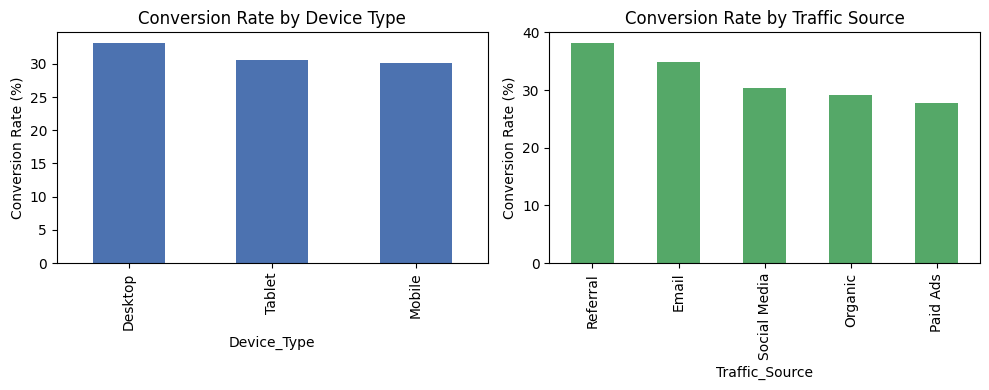

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

train.groupby("Device_Type")["Converted"].mean().mul(100).sort_values(ascending=False).plot(
    kind="bar", ax=axes[0], color="#4C72B0"
)
axes[0].set_title("Conversion Rate by Device Type")
axes[0].set_ylabel("Conversion Rate (%)")

train.groupby("Traffic_Source")["Converted"].mean().mul(100).sort_values(ascending=False).plot(
    kind="bar", ax=axes[1], color="#55A868"
)
axes[1].set_title("Conversion Rate by Traffic Source")
axes[1].set_ylabel("Conversion Rate (%)")

plt.tight_layout()
plt.show()

## 5. Train / Validation Split

In [5]:
TARGET = "Converted"
ID_COL = "User_ID"

X = train.drop(columns=[TARGET, ID_COL])
y = train[TARGET]

X_train2, X_valid, y_train2, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Training Set:", X_train2.shape)
print("Validation Set:", X_valid.shape)

Training Set: (8000, 12)
Validation Set: (2000, 12)


## 6. Feature Engineering

A few lightweight, defensible features derived from the existing columns:
- `Engagement_Rate` = Products_Viewed / Pages_Viewed (how much of the browsing turns into product views)
- `Time_Per_Page` = Time_On_Site / Pages_Viewed (browsing speed/intensity)
- `Log_Income` = log1p(Income) (Income is right-skewed; log-transform helps the linear model)

This is wrapped in a `FunctionTransformer` so it's applied identically and automatically to train, validation, and both test sets inside the pipeline — no risk of forgetting to apply it somewhere, which is a common source of train/test mismatch bugs.

In [6]:
def engineer_features(df):
    df = df.copy()
    df["Engagement_Rate"] = df["Products_Viewed"] / df["Pages_Viewed"].replace(0, np.nan)
    df["Time_Per_Page"] = df["Time_On_Site"] / df["Pages_Viewed"].replace(0, np.nan)
    df["Log_Income"] = np.log1p(df["Income"])
    return df

feature_engineer = FunctionTransformer(engineer_features)

# Preview on a copy so we can see the new columns
engineer_features(X_train2).head()

,Age,Income,City_Tier,Device_Type,Traffic_Source,Pages_Viewed,Products_Viewed,Time_On_Site,Previous_Purchases,Discount_Seen,Browser_Version,Campaign_Code,Engagement_Rate,Time_Per_Page,Log_Income
2098,24.0,89970.449215,1,Desktop,Email,19,19,8.15,2,0,19,5554,1.000000,0.428947,11.407248
423,44.0,73118.256481,2,Mobile,Organic,7,10,10.11,1,1,22,5878,1.428571,1.444286,11.199847
2853,50.0,111277.341392,2,Mobile,Organic,14,16,17.10,7,0,4,3635,1.142857,1.221429,11.619790
2267,56.0,50772.206106,2,Desktop,Referral,13,14,25.47,3,1,1,8956,1.076923,1.959231,10.835124
7427,NaN,75068.125553,3,Mobile,Email,7,6,10.00,2,1,19,7019,0.857143,1.428571,11.226165


## 7. Preprocessing Pipeline

In [7]:
numeric_features = X_train2.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train2.select_dtypes(include=["object"]).columns.tolist()
numeric_features_eng = numeric_features + ["Engagement_Rate", "Time_Per_Page", "Log_Income"]

print("Numeric (incl. engineered):", numeric_features_eng)
print("Categorical:", categorical_features)

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features_eng),
    ("cat", categorical_transformer, categorical_features)
])

def make_pipeline(model):
    return Pipeline([
        ("feature_engineering", feature_engineer),
        ("preprocessor", preprocessor),
        ("model", model)
    ])

Numeric (incl. engineered): ['Age', 'Income', 'City_Tier', 'Pages_Viewed', 'Products_Viewed', 'Time_On_Site', 'Previous_Purchases', 'Discount_Seen', 'Browser_Version', 'Campaign_Code', 'Engagement_Rate', 'Time_Per_Page', 'Log_Income']
Categorical: ['Device_Type', 'Traffic_Source']


## 8. Model Comparison (Cross-Validated)

In [8]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1, class_weight="balanced"),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=RANDOM_STATE),
}

if HAS_XGB:
    neg, pos = np.bincount(y_train2)
    models["XGBoost"] = XGBClassifier(
        n_estimators=300, random_state=RANDOM_STATE, eval_metric="logloss",
        scale_pos_weight=neg / pos
    )

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}

for name, model in models.items():
    pipe = make_pipeline(model)
    scores = cross_val_score(pipe, X_train2, y_train2, cv=cv, scoring="f1", n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:22s}  F1 = {scores.mean():.4f} +/- {scores.std():.4f}")

Logistic Regression     F1 = 0.5616 +/- 0.0080
Random Forest           F1 = 0.3239 +/- 0.0182
HistGradientBoosting    F1 = 0.3911 +/- 0.0148
XGBoost                 F1 = 0.4488 +/- 0.0200


## 9. Fit Candidates on the Hold-Out Split & Tune Thresholds

Cross-validation picks the best *model*; the held-out validation split is then used to pick a *decision threshold* for each model (searched over 0.05–0.95), the way the original notebook did for Logistic Regression — but now every model gets the same treatment.

In [9]:
def best_threshold(y_true, probs, grid=np.arange(0.05, 0.96, 0.01)):
    best_f1, best_t = 0.0, 0.5
    for t in grid:
        f1 = f1_score(y_true, (probs >= t).astype(int))
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t, best_f1

fitted_pipelines = {}
threshold_results = {}

for name, model in models.items():
    pipe = make_pipeline(model)
    pipe.fit(X_train2, y_train2)
    probs = pipe.predict_proba(X_valid)[:, 1]

    default_f1 = f1_score(y_valid, (probs >= 0.5).astype(int))
    t, tuned_f1 = best_threshold(y_valid, probs)

    fitted_pipelines[name] = pipe
    threshold_results[name] = {"default_f1": default_f1, "best_threshold": t, "tuned_f1": tuned_f1}
    print(f"{name:22s}  default(0.5) F1={default_f1:.4f}   tuned F1={tuned_f1:.4f} @ threshold={t:.2f}")

best_model_name = max(threshold_results, key=lambda k: threshold_results[k]["tuned_f1"])
best_threshold_value = threshold_results[best_model_name]["best_threshold"]
print("\nBest model:", best_model_name, "| threshold:", best_threshold_value)

Logistic Regression     default(0.5) F1=0.5731   tuned F1=0.5825 @ threshold=0.46
Random Forest           default(0.5) F1=0.3315   tuned F1=0.5674 @ threshold=0.24
HistGradientBoosting    default(0.5) F1=0.3680   tuned F1=0.5671 @ threshold=0.27
XGBoost                 default(0.5) F1=0.4502   tuned F1=0.5324 @ threshold=0.10

Best model: Logistic Regression | threshold: 0.4600000000000001


## 10. Diagnostics for the Best Model

F1 alone can hide *how* a model is failing. A confusion matrix and ROC-AUC give a fuller picture, and the threshold-vs-F1 curve shows how sensitive the score is to the exact cutoff chosen (a very sharp, narrow peak would be a sign of overfitting the threshold to this particular validation split).

              precision    recall  f1-score   support

           0       0.86      0.60      0.71      1383
           1       0.47      0.78      0.58       617

    accuracy                           0.66      2000
   macro avg       0.66      0.69      0.65      2000
weighted avg       0.74      0.66      0.67      2000

ROC-AUC: 0.7365954499590419
Confusion Matrix:
 [[832 551]
 [137 480]]


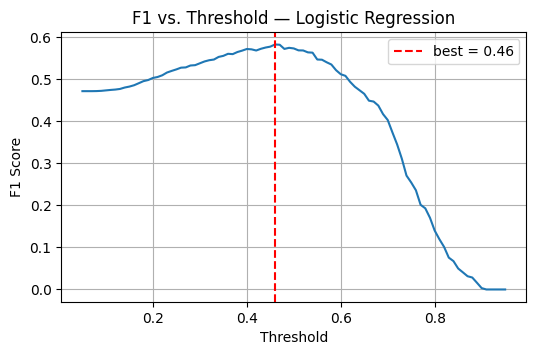

In [10]:
best_pipe = fitted_pipelines[best_model_name]
best_probs = best_pipe.predict_proba(X_valid)[:, 1]
best_preds = (best_probs >= best_threshold_value).astype(int)

print(classification_report(y_valid, best_preds))
print("ROC-AUC:", roc_auc_score(y_valid, best_probs))
print("Confusion Matrix:\n", confusion_matrix(y_valid, best_preds))

grid = np.arange(0.05, 0.96, 0.01)
f1s = [f1_score(y_valid, (best_probs >= t).astype(int)) for t in grid]

plt.figure(figsize=(6, 3.5))
plt.plot(grid, f1s)
plt.axvline(best_threshold_value, color="red", linestyle="--", label=f"best = {best_threshold_value:.2f}")
plt.title(f"F1 vs. Threshold — {best_model_name}")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.legend()
plt.grid(True)
plt.show()

## 11. Model Comparison Chart

Plotted from the actual computed scores (the original hard-coded the numbers into the chart, which silently goes stale the moment the models are retrained).

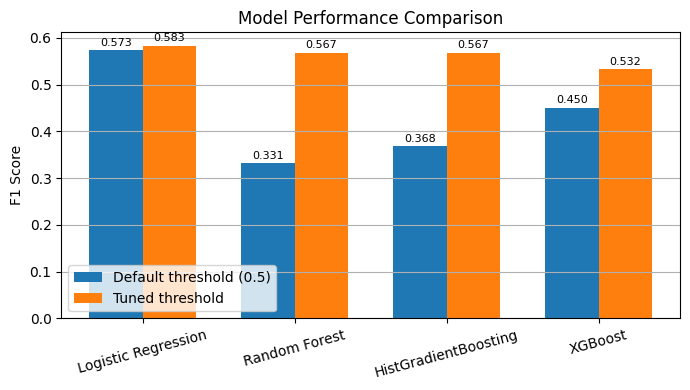

In [11]:
names = list(threshold_results.keys())
default_scores = [threshold_results[n]["default_f1"] for n in names]
tuned_scores = [threshold_results[n]["tuned_f1"] for n in names]

x = np.arange(len(names))
width = 0.35

plt.figure(figsize=(7, 4))
plt.bar(x - width/2, default_scores, width, label="Default threshold (0.5)")
plt.bar(x + width/2, tuned_scores, width, label="Tuned threshold")
plt.xticks(x, names, rotation=15)
plt.ylabel("F1 Score")
plt.title("Model Performance Comparison")
plt.legend()
plt.grid(True, axis="y")

for xi, s in zip(x - width/2, default_scores):
    plt.text(xi, s + 0.01, f"{s:.3f}", ha="center", fontsize=8)
for xi, s in zip(x + width/2, tuned_scores):
    plt.text(xi, s + 0.01, f"{s:.3f}", ha="center", fontsize=8)

plt.tight_layout()
plt.show()

## 12. Feature Importance (if the best model is tree-based)

In [12]:
model_step = best_pipe.named_steps["model"]

if hasattr(model_step, "feature_importances_"):
    feature_names = best_pipe.named_steps["preprocessor"].get_feature_names_out()
    importances = pd.Series(model_step.feature_importances_, index=feature_names)
    importances = importances.sort_values(ascending=False).head(15)

    plt.figure(figsize=(6, 5))
    importances.sort_values().plot(kind="barh", color="#C44E52")
    plt.title(f"Top Feature Importances — {best_model_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
else:
    print(f"{best_model_name} does not expose feature_importances_ (e.g. Logistic Regression) — "
          "skip, or inspect model.coef_ instead for linear models.")

Logistic Regression does not expose feature_importances_ (e.g. Logistic Regression) — skip, or inspect model.coef_ instead for linear models.


## 13. Final Training & Submission

Refit the *best* pipeline (model + tuned threshold chosen above) on the full training set, then predict on `private_test`. `User_ID` is kept aside purely as the submission identifier and dropped from the feature matrix.

In [13]:
final_pipe = make_pipeline(models[best_model_name])
final_pipe.fit(X, y)

X_private = private_test.drop(columns=[ID_COL])
private_probs = final_pipe.predict_proba(X_private)[:, 1]
private_preds = (private_probs >= best_threshold_value).astype(int)

submission = pd.DataFrame({
    "User_ID": private_test[ID_COL],
    "Converted": private_preds
})
submission.to_csv("submission.csv", index=False)

print(f"Final model: {best_model_name} | threshold: {best_threshold_value:.2f}")
print(submission.head())
print("\nFile saved: submission.csv")

Final model: Logistic Regression | threshold: 0.46
   User_ID  Converted
0   103001          0
1   103002          0
2   103003          1
3   103004          1
4   103005          0

File saved: submission.csv
